In [41]:
import numpy as np

def cf_shell(label="shell", total_time=20, time_step=0.25/30, 
             b=0.1, d=4, z=0, a=1, phi=0, psi=0, 
             n=0, n_amp=0, c=0, c_amp=0, k=0, 
             points_on_aperture=1, length=1, smooth=True):
    times = np.arange(start=0, stop=total_time, step=time_step)

    sin_t = np.sin(times)
    cos_t = np.cos(times)
    axial_term = 1 + c_amp * np.sin(c * times)

    # Adjust spiral term calculation to ensure all operations are supported
    spiral_term = np.exp(b * times) - (1 / (times + 1))
    spiral_term = spiral_term[:, np.newaxis]  # reshape for broadcasting

    gamma_exp = np.exp(b * times)[:, np.newaxis]  # reshape for broadcasting
    gamma_vec = np.stack([
        d * sin_t,
        d * cos_t,
        z * np.ones_like(times)  # ensure this is an array
    ], axis=-1)  # stack along the last dimension

    gamma = gamma_exp * gamma_vec

    R = np.array([[np.cos(psi), -np.sin(psi), 0],
                  [np.sin(psi),  np.cos(psi), 0],
                  [0,            0,           1]])

    # Normal vector
    N = np.stack([
        b * cos_t - sin_t,
        -b * sin_t - cos_t,
        np.zeros_like(times)  # ensure this is an array
    ], axis=-1) / np.sqrt(b**2 + 1)

    # Binormal vector
    B = np.stack([
        b * z * (b * sin_t + cos_t),
        b * z * (b * cos_t - sin_t),
        d * (b**2 + 1) * np.ones_like(times)  # ensure this is an array
    ], axis=-1) / np.sqrt((b**2 + 1) * ((b**2 + 1) * d**2 + b**2 * z**2))

    # Compute the transformation for current t
    transformation_matrix = (a * np.sin(phi) + np.cos(phi)) * N + (a * np.sin(phi) - np.cos(phi) + k) * B
    C = spiral_term * np.matmul(R, transformation_matrix.T).T  # adjust the matrix multiplication and broadcasting

    lam = gamma + C
    return lam

# You can now use this function by calling it with appropriate parameters:
result = cf_shell()

[[ 0.00000000e+00  4.00000000e+00  0.00000000e+00]
 [ 3.41905635e-02  3.99413550e+00 -9.09814346e-03]
 [ 6.82721984e-02  3.98811644e+00 -1.80614990e-02]
 ...
 [ 2.03447217e+01  8.90384496e+00 -7.32293073e+00]
 [ 2.04351850e+01  8.74124977e+00 -7.32909439e+00]
 [ 2.05243642e+01  8.57777065e+00 -7.33526317e+00]]


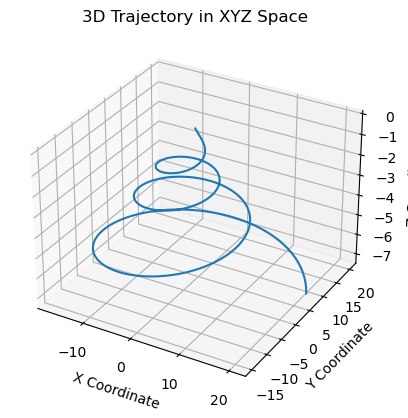

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assume 'result' is the output from your cf_shell function
data = result

# Create a figure for plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D trajectory
ax.plot(data[:, 0], data[:, 1], data[:, 2])

# Label the axes
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

# Title for the plot
ax.set_title('3D Trajectory in XYZ Space')

# Show the plot
plt.show()
